### Clustering

##### La aplicación del algoritmo de clustering requiere que conozcamos el número de clusters en los que se va a dividir los productos. Para ello, utilizamos la regla del codo.

In [2]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

c:\Users\santi\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
# Cargar el dataset en df
df = pd.read_csv('dataset_formateado.csv')

# Eliminamos las entradas del dataset que hayan sido devoluciones
df = df[df['Sale or Return'] == 'sale']

# Crear columna que contenga la fecha y la hora de la compra
df['Date'] = df['Date'].astype(str)
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df = df.drop('Date',axis=1)
df = df.drop('Time',axis=1)

# Definir una compra como el conjunto de productos vendidos en el mismo minuto de la misma Fecha y Hora 
df['transaction_id'] =  df['Datetime'].dt.floor('min').factorize()[0] + 1
# Eliminar las compras que no tengan mas de 1 producto ya que no tiene sentido considerarlas
df = df[df['transaction_id'].map(df['transaction_id'].value_counts()) > 1]

# Crear la matriz de compras 
product_matrix = pd.crosstab(df['transaction_id'], df['Item Code'])

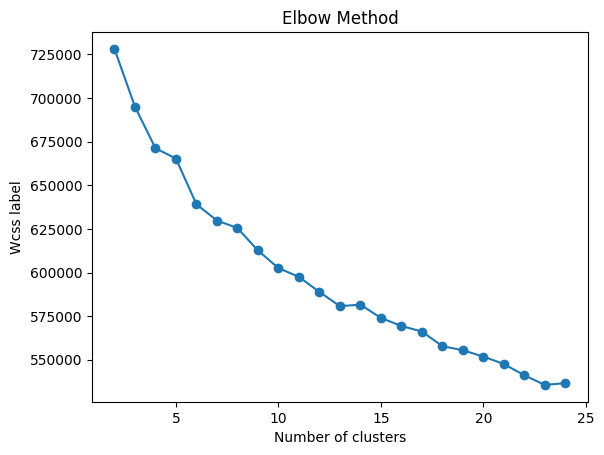

In [29]:
# Regla del Codo
wcss =[]
for i in range(2,25):
    kmeans = KMeans(n_clusters=i,init='k-means++',n_init=10,random_state=0)
    kmeans.fit(product_matrix)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,25),wcss,marker = 'o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Wcss label')
plt.show()

##### Identificamos 3 codos que podrían ser de utilidad {5,7,13}. Vamos a probar para ver cual de ellos nos devuelve el resultado mayor claridad visual, un número manejable de segmentos para análisis o recomendación y una buena separación sin exceso de mezcla o pérdida de información.

In [4]:
# Predecir los clusters usando el algoritmo de las k-medias
kmeans = KMeans(n_clusters=13,random_state=42)
product_matrix['Cluster'] = kmeans.fit_predict(product_matrix)

# Se crea un dataframe siendo cada fila un cluster con su centroide y cada columna un producto dentro del cluster
centroides = kmeans.cluster_centers_
product_matrix1 = product_matrix.drop('Cluster',axis=1)
dataframe = pd.DataFrame(centroides, columns= product_matrix1.columns)

#Recoger n productos de los 5 primeros clusters
n_clusters= 5
dicc = dict()
for cluster_id in range(n_clusters):
    top_products = dataframe.iloc[cluster_id].nlargest(5)  # Selecciona los top N productos
    dicc[cluster_id] = top_products.to_dict()
    
# Devuelve el nombre de los productos que se han seleccionado anteriormente 
dicc1 = dict()
for cluster in dicc:
    for codigo_producto in dicc[cluster]:
        nombre_producto = df.loc[df['Item Code'] == codigo_producto, 'Item Name'].values[0]
        if cluster not in dicc1:
            dicc1[cluster] = [nombre_producto]
        else:
            dicc1[cluster].append(nombre_producto)

C:\Users\santi\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


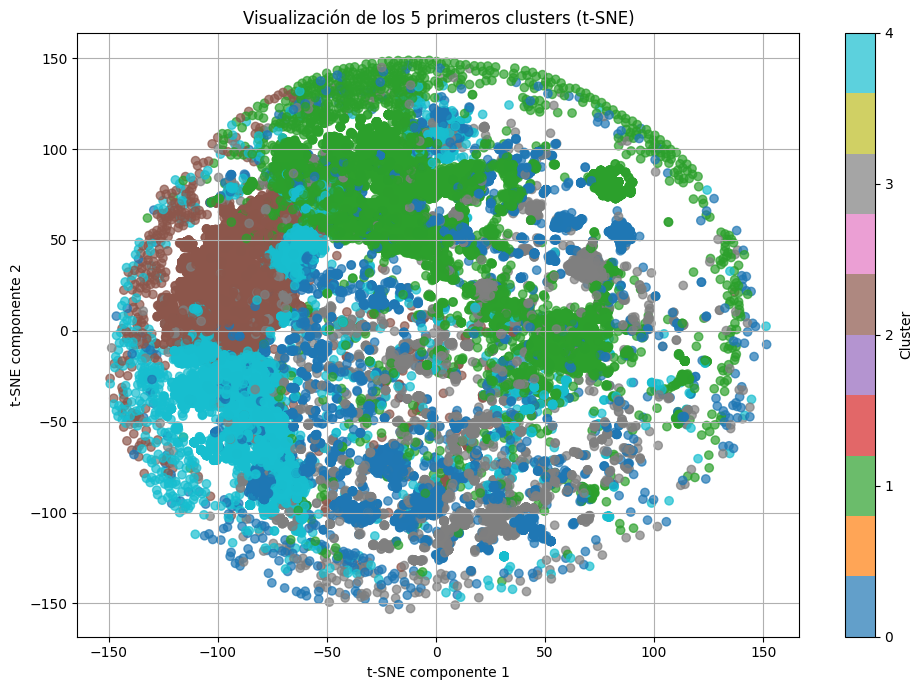

In [31]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Aplicar t-SNE para reducción de dimensionalidad
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(product_matrix1)

# Predecir los clusters
clusters = kmeans.predict(product_matrix1)

# Filtrar solo los primeros 5 clusters
mask = np.isin(clusters, list(range(5)))
tsne_filtered = tsne_result[mask]
clusters_filtered = np.array(clusters)[mask]

# Graficar
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    tsne_filtered[:, 0],
    tsne_filtered[:, 1],
    c=clusters_filtered,
    cmap='tab10',
    alpha=0.7
)
plt.title("Visualización de los 5 primeros clusters (t-SNE)")
plt.xlabel("t-SNE componente 1")
plt.ylabel("t-SNE componente 2")
plt.colorbar(scatter, ticks=range(5), label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


#### Observamos que no hay una diferenciación clara entre clusters por lo que vamos a probar a disminuir el número de estos

In [5]:
# Predecir los clusters usando el algoritmo de las k-medias
kmeans = KMeans(n_clusters=7,random_state=42)
product_matrix['Cluster'] = kmeans.fit_predict(product_matrix)

# Se crea un dataframe siendo cada fila un cluster con su centroide y cada columna un producto dentro del cluster
centroides = kmeans.cluster_centers_
product_matrix1 = product_matrix.drop('Cluster',axis=1)
dataframe = pd.DataFrame(centroides, columns= product_matrix1.columns)

#Recoger n productos de los 5 primeros clusters
n_clusters= 5
dicc = dict()
for cluster_id in range(n_clusters):
    top_products = dataframe.iloc[cluster_id].nlargest(5)  # Selecciona los top N productos
    dicc[cluster_id] = top_products.to_dict()
    
# Devuelve el nombre de los productos que se han seleccionado anteriormente 
dicc1 = dict()
for cluster in dicc:
    for codigo_producto in dicc[cluster]:
        nombre_producto = df.loc[df['Item Code'] == codigo_producto, 'Item Name'].values[0]
        if cluster not in dicc1:
            dicc1[cluster] = [nombre_producto]
        else:
            dicc1[cluster].append(nombre_producto)


TypeError: Feature names are only supported if all input features have string names, but your input has ['int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.

In [ ]:
# Convertir todos los nombres de columnas a strings antes del clustering
product_matrix.columns = product_matrix.columns.astype(str)

# Asegurarse de que no haya columna 'Cluster' antes del entrenamiento
if 'Cluster' in product_matrix.columns:
    product_matrix_clean = product_matrix.drop('Cluster', axis=1)
else:
    product_matrix_clean = product_matrix.copy()

# Guardar las columnas que se usarán para el clustering
feature_columns = product_matrix_clean.columns.tolist()

# Predecir los clusters usando el algoritmo de las k-medias
kmeans = KMeans(n_clusters=7, random_state=42)
cluster_labels = kmeans.fit_predict(product_matrix_clean)

# Añadir los labels de cluster al DataFrame original
product_matrix['Cluster'] = cluster_labels

# Crear dataframe de centroides usando las mismas columnas que se usaron para el entrenamiento
centroides = kmeans.cluster_centers_
dataframe = pd.DataFrame(centroides, columns=feature_columns)

print(f"Forma de centroides: {centroides.shape}")
print(f"Número de columnas de características: {len(feature_columns)}")
print(f"Forma del DataFrame de centroides: {dataframe.shape}")

# Recoger n productos de los 5 primeros clusters
n_clusters = 5
dicc = dict()
for cluster_id in range(n_clusters):
    top_products = dataframe.iloc[cluster_id].nlargest(5)  # Selecciona los top N productos
    dicc[cluster_id] = top_products.to_dict()
    
# Devuelve el nombre de los productos que se han seleccionado anteriormente 
dicc1 = dict()
for cluster in dicc:
    for codigo_producto in dicc[cluster]:
        # Convertir codigo_producto de vuelta a int si es necesario para la búsqueda
        try:
            codigo_producto_int = int(codigo_producto)
        except ValueError:
            codigo_producto_int = codigo_producto
        
        # Buscar el nombre del producto
        producto_encontrado = df.loc[df['Item Code'] == codigo_producto_int, 'Item Name']
        
        if not producto_encontrado.empty:
            nombre_producto = producto_encontrado.values[0]
            if cluster not in dicc1:
                dicc1[cluster] = [nombre_producto]
            else:
                dicc1[cluster].append(nombre_producto)

# Mostrar los resultados
print("\nProductos principales por cluster:")
for cluster, productos in dicc1.items():
    print(f"\nCluster {cluster}:")
    for i, producto in enumerate(productos, 1):
        print(f"  {i}. {producto}")

# Información adicional del clustering
print(f"\nInformación del clustering:")
print(f"Número de clusters: {kmeans.n_clusters}")
print(f"Número de características: {centroides.shape[1]}")
print(f"Distribución de puntos por cluster:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} puntos")

Forma de centroides: (7, 244)
Número de columnas de características: 244
Forma del DataFrame de centroides: (7, 244)

Productos principales por cluster:

Cluster 0:
  1. Zhuyecai
  2. Wuhu Green Pepper (1)
  3. Broccoli
  4. Yunnan Shengcai
  5. Luosi Pepper

Cluster 1:
  1. Broccoli
  2. Wuhu Green Pepper (1)
  3. Xixia Mushroom (1)
  4. Net Lotus Root (1)
  5. Yunnan Shengcai

Cluster 2:
  1. Xixia Mushroom (1)
  2. Wuhu Green Pepper (1)
  3. Net Lotus Root (1)
  4. Yunnan Shengcai
  5. Paopaojiao (Jingpin)

Cluster 3:
  1. Wuhu Green Pepper (1)
  2. Net Lotus Root (1)
  3. Eggplant (2)
  4. Yunnan Shengcai
  5. Yunnan Lettuces

Cluster 4:
  1. Zhuyecai
  2. Xixia Black Mushroom (1)
  3. Yunnan Shengcai
  4. Luosi Pepper
  5. Eggplant (2)

Información del clustering:
Número de clusters: 7
Número de características: 244
Distribución de puntos por cluster:
  Cluster 0: 721 puntos
  Cluster 1: 40109 puntos
  Cluster 2: 26819 puntos
  Cluster 3: 35010 puntos
  Cluster 4: 11587 puntos
  C

c:\Users\santi\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


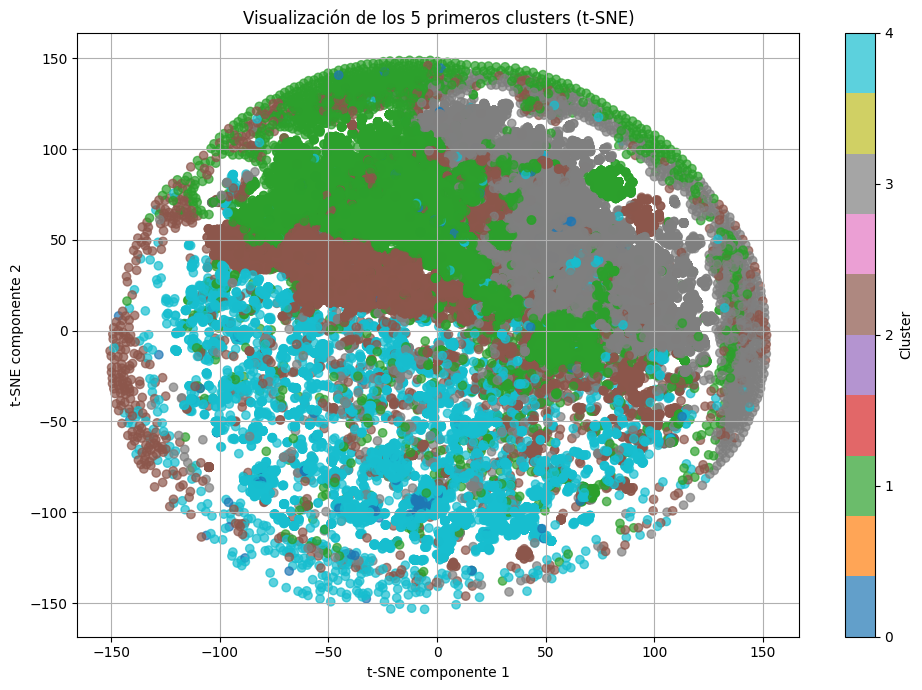

In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Aplicar t-SNE para reducción de dimensionalidad
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(product_matrix1)

# Predecir los clusters
clusters = kmeans.predict(product_matrix1)

# Filtrar solo los primeros 5 clusters
mask = np.isin(clusters, list(range(5)))
tsne_filtered = tsne_result[mask]
clusters_filtered = np.array(clusters)[mask]

# Graficar
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    tsne_filtered[:, 0],
    tsne_filtered[:, 1],
    c=clusters_filtered,
    cmap='tab10',
    alpha=0.7
)
plt.title("Visualización de los 5 primeros clusters (t-SNE)")
plt.xlabel("t-SNE componente 1")
plt.ylabel("t-SNE componente 2")
plt.colorbar(scatter, ticks=range(5), label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


#### Probamos a volver a bajar para intentar obtener mejores resultados


In [18]:
# Convertir todos los nombres de columnas a strings antes del clustering
product_matrix.columns = product_matrix.columns.astype(str)

# Asegurarse de que no haya columna 'Cluster' antes del entrenamiento
if 'Cluster' in product_matrix.columns:
    product_matrix_clean = product_matrix.drop('Cluster', axis=1)
else:
    product_matrix_clean = product_matrix.copy()

# Guardar las columnas que se usarán para el clustering
feature_columns = product_matrix_clean.columns.tolist()

# Predecir los clusters usando el algoritmo de las k-medias
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(product_matrix_clean)

# Añadir los labels de cluster al DataFrame original
product_matrix['Cluster'] = cluster_labels

# Crear dataframe de centroides usando las mismas columnas que se usaron para el entrenamiento
centroides = kmeans.cluster_centers_
dataframe = pd.DataFrame(centroides, columns=feature_columns)

print(f"Forma de centroides: {centroides.shape}")
print(f"Número de columnas de características: {len(feature_columns)}")
print(f"Forma del DataFrame de centroides: {dataframe.shape}")

# Recoger n productos de los 5 primeros clusters
n_clusters = 5
dicc = dict()
for cluster_id in range(n_clusters):
    top_products = dataframe.iloc[cluster_id].nlargest(5)  # Selecciona los top N productos
    dicc[cluster_id] = top_products.to_dict()
    
# Devuelve el nombre de los productos que se han seleccionado anteriormente 
dicc1 = dict()
for cluster in dicc:
    for codigo_producto in dicc[cluster]:
        # Convertir codigo_producto de vuelta a int si es necesario para la búsqueda
        try:
            codigo_producto_int = int(codigo_producto)
        except ValueError:
            codigo_producto_int = codigo_producto
        
        # Buscar el nombre del producto
        producto_encontrado = df.loc[df['Item Code'] == codigo_producto_int, 'Item Name']
        
        if not producto_encontrado.empty:
            nombre_producto = producto_encontrado.values[0]
            if cluster not in dicc1:
                dicc1[cluster] = [nombre_producto]
            else:
                dicc1[cluster].append(nombre_producto)

# Mostrar los resultados
print("\nProductos principales por cluster:")
for cluster, productos in dicc1.items():
    print(f"\nCluster {cluster}:")
    for i, producto in enumerate(productos, 1):
        print(f"  {i}. {producto}")

# Información adicional del clustering
print(f"\nInformación del clustering:")
print(f"Número de clusters: {kmeans.n_clusters}")
print(f"Número de características: {centroides.shape[1]}")
print(f"Distribución de puntos por cluster:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} puntos")

Forma de centroides: (5, 244)
Número de columnas de características: 244
Forma del DataFrame de centroides: (5, 244)

Productos principales por cluster:

Cluster 0:
  1. Zhuyecai
  2. Wuhu Green Pepper (1)
  3. Broccoli
  4. Yunnan Shengcai
  5. Luosi Pepper

Cluster 1:
  1. Broccoli
  2. Yunnan Shengcai
  3. Net Lotus Root (1)
  4. Paopaojiao (Jingpin)
  5. Eggplant (2)

Cluster 2:
  1. Xixia Mushroom (1)
  2. Broccoli
  3. Wuhu Green Pepper (1)
  4. Net Lotus Root (1)
  5. Yunnan Shengcai

Cluster 3:
  1. Wuhu Green Pepper (1)
  2. Broccoli
  3. Net Lotus Root (1)
  4. Yunnan Shengcai
  5. Eggplant (2)

Cluster 4:
  1. Zhuyecai
  2. Xixia Black Mushroom (1)
  3. Broccoli
  4. Yunnan Shengcai
  5. Eggplant (2)

Información del clustering:
Número de clusters: 5
Número de características: 244
Distribución de puntos por cluster:
  Cluster 0: 723 puntos
  Cluster 1: 129372 puntos
  Cluster 2: 33548 puntos
  Cluster 3: 41581 puntos
  Cluster 4: 14069 puntos


c:\Users\santi\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


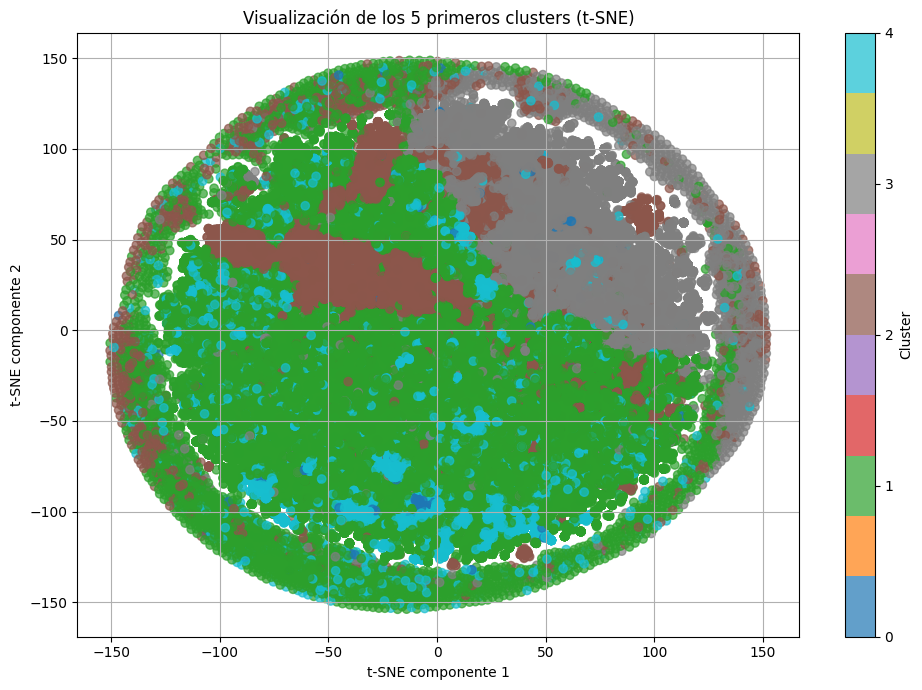

In [19]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Aplicar t-SNE para reducción de dimensionalidad
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(product_matrix1)

# Predecir los clusters
clusters = kmeans.predict(product_matrix1)

# Filtrar solo los primeros 5 clusters
mask = np.isin(clusters, list(range(5)))
tsne_filtered = tsne_result[mask]
clusters_filtered = np.array(clusters)[mask]

# Graficar
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    tsne_filtered[:, 0],
    tsne_filtered[:, 1],
    c=clusters_filtered,
    cmap='tab10',
    alpha=0.7
)
plt.title("Visualización de los 5 primeros clusters (t-SNE)")
plt.xlabel("t-SNE componente 1")
plt.ylabel("t-SNE componente 2")
plt.colorbar(scatter, ticks=range(5), label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


#### Se ve claramente que el mejor resultado lo devuelve el algoritmo con 7 clusters ya que: Visualmente es la más clara, los clusters están bien distribuidos, hay regiones diferenciadas por color, y no domina uno solo. Se observan agrupaciones significativas y un nivel manejable de solapamiento. Es un buen punto medio: ni demasiados clusters pequeños (como con 13), ni un gigante verde que lo absorbe todo (como con 5).

 #### En el algoritmo con 13 clusters hay demasiada fragmentación, con clusters que se mezclan visualmente y no se distinguen bien. Puede ser útil si estamos buscando microsegmentos, pero no es óptimo para interpretación general o recomendaciones.

#### En el algoritmo con 5 clusters uno o dos clusters absorben casi todos los puntos (el verde en especial), se pierde detalle, hay demasiada generalización y  poca utilidad si quieres hacer recomendaciones específicas basadas en comportamiento.

## Caracterización de los clusters

In [ ]:
n_clusters = 7
caracteristicas_clusters = dict()

for cluster_id in range(n_clusters):
    # Top productos por valor del centroide (los más representativos del cluster)
    top_codigos = dataframe.iloc[cluster_id].nlargest(10)  # Top 10 productos
    productos_cluster = []

    for codigo_producto, score in top_codigos.items():
        nombre = df.loc[df['Item Code'] == codigo_producto, 'Item Name'].values[0]
        categoria = df.loc[df['Item Code'] == codigo_producto, 'Category Name'].values[0]
        productos_cluster.append({
            'Código': codigo_producto,
            'Nombre': nombre,
            'Peso en centroide': round(score, 4),
            'Categoría del producto': categoria
        })

    caracteristicas_clusters[cluster_id] = productos_cluster

for cluster_id, productos in caracteristicas_clusters.items():
    print(f"\n--- Cluster {cluster_id} ---")
    for p in productos:
        print(f"{p['Nombre']} (Código: {p['Código']}) - Peso: {p['Peso en centroide']} - Categoría: {p['Categoría del producto']}")


In [ ]:
# El entorno se ha reiniciado. Reejecutamos el proceso desde el principio.
import pandas as pd

# Cargamos los archivos necesarios
df = pd.read_csv("dataset_formateado.csv")
df = df[df['Sale or Return'] == 'sale']
df['Date'] = df['Date'].astype(str)
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df = df.drop(['Date', 'Time'], axis=1)
df['transaction_id'] = df['Datetime'].dt.floor('min').factorize()[0] + 1
df = df[df['transaction_id'].map(df['transaction_id'].value_counts()) > 1]

# Matriz de productos
product_matrix = pd.crosstab(df['transaction_id'], df['Item Code'])

# Clustering
from sklearn.cluster import KMeans

n_clusters = 7
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
product_matrix['Cluster'] = kmeans.fit_predict(product_matrix)
product_matrix1 = product_matrix.drop('Cluster', axis=1)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=product_matrix1.columns)

# Enriquecimiento de caracterización
caracteristicas_clusters = dict()

for cluster_id in range(n_clusters):
    top_codigos = centroids.iloc[cluster_id].nlargest(10)
    productos_cluster = []

    for codigo_producto, score in top_codigos.items():
        sub_df = df[df['Item Code'] == codigo_producto]
        nombre = sub_df['Item Name'].iloc[0]
        
        # Nuevas métricas
        total_ventas = len(sub_df)
        importe_total = sub_df['Unit Selling Price (EUR/kg)'].sum()
        media_importe = sub_df['Unit Selling Price (EUR/kg)'].mean()
        hora_mas_frecuente = sub_df['Datetime'].dt.hour.mode()[0]

        productos_cluster.append({
            'Código': codigo_producto,
            'Nombre': nombre,
            'Peso en centroide': round(score, 4),
            'Total ventas': total_ventas,
            'Importe total (€)': round(importe_total, 2),
            'Importe medio (€)': round(media_importe, 2),
            'Hora más frecuente': hora_mas_frecuente
        })

    caracteristicas_clusters[cluster_id] = productos_cluster

# Preparar resultados
flat_data = []
for cluster_id, productos in caracteristicas_clusters.items():
    for p in productos:
        p_flat = p.copy()
        p_flat['Cluster'] = cluster_id
        flat_data.append(p_flat)

df_caracterizacion = pd.DataFrame(flat_data)



In [19]:
print(df_caracterizacion[df_caracterizacion['Cluster'] == 4])

    Código                    Nombre  Peso en centroide  Total ventas  \
40      22                  Zhuyecai             0.5768         12746   
41      67  Xixia Black Mushroom (1)             0.4980          8927   
42       4           Yunnan Shengcai             0.1200         31298   
43      36              Luosi Pepper             0.1123         17655   
44      26              Eggplant (2)             0.1112         22057   
45      41        Net Lotus Root (1)             0.0955         31806   
46       0      Paopaojiao (Jingpin)             0.0931         20829   
47      20               Hongshujian             0.0720         10509   
48       7           Yunnan Lettuces             0.0710         18804   
49      11                  Amaranth             0.0669          8062   

    Importe total (€)  Importe medio (€)  Hora más frecuente  Cluster  
40            9131.36               0.72                  10        4  
41           24921.49               2.79            